In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("wandb.csv")

In [3]:
data.columns

Index(['Name', 'State', 'Notes', 'User', 'Tags', 'Created', 'Runtime', 'Sweep',
       'batch_size', 'class weights:', 'drop out',
       'feature_extraction_config.data.batch_size',
       'feature_extraction_config.data.mask_threshold',
       'feature_extraction_config.data.target_mpp',
       'feature_extraction_config.data.tile_overlap',
       'feature_extraction_config.data.tile_size',
       'feature_extraction_config.model.feature_dim',
       'feature_extraction_config.model.name', 'hidden_dim', 'k_folds', 'lr',
       'nr_epochs', 'wd', 'epoch', 'final_val_HGD_auc', 'final_val_HGD_f1',
       'final_val_HGD_precision', 'final_val_HGD_recall', 'final_val_LGD_auc',
       'final_val_LGD_f1', 'final_val_LGD_precision', 'final_val_LGD_recall',
       'final_val_NDBE_auc', 'final_val_NDBE_f1', 'final_val_NDBE_precision',
       'final_val_NDBE_recall', 'final_val_accuracy', 'fold/convergence_epoch',
       'fold/loss_instability', 'fold/val_accuracy',
       'summary/mean_converg

In [5]:
data = data[data["Name"].str.contains("conv")].iloc[::-1]
data

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,batch_size,class weights:,...,summary/mean_loss_instability,summary/mean_val_accuracy,summary/val_accuracy_variance,train_accuracy_epoch,train_accuracy_step,train_loss_epoch,train_loss_step,trainer/global_step,val_accuracy,val_loss
99,convmetrics_Pathologist_1_fold_1,finished,-,NaN,NaN,2025-05-05T13:26:28.000Z,11884,NaN,1,"[0.6494949460029602,0.8784152865409851,3.10628...",...,NaN,0.735099,0.194728,0.953344,1,0.187431,0.035602,96450,0.763975,0.660411
98,convmetrics_Pathologist_1_fold_2,finished,-,NaN,NaN,2025-05-05T13:33:38.000Z,11971,NaN,1,"[0.6455823183059692,0.904360055923462,2.896396...",...,NaN,0.529801,0.249112,0.953344,1,0.173035,0.026456,96450,0.732919,0.778395
97,convmetrics_Pathologist_1_fold_3,finished,-,NaN,NaN,2025-05-05T13:34:13.000Z,12458,NaN,1,"[0.6378968358039856,0.9278499484062196,2.82017...",...,NaN,0.476821,0.249463,0.937792,1,0.218681,0.077753,96450,0.776398,0.713403
96,convmetrics_Pathologist_1_fold_4,finished,-,NaN,NaN,2025-05-05T13:34:47.000Z,12969,NaN,1,"[0.6360039710998535,0.9318840503692628,2.82017...",...,NaN,0.993377,0.006579,0.948678,1,0.203973,0.008893,96450,0.751553,0.697877
95,convmetrics_Pathologist_1_fold_5,finished,-,NaN,NaN,2025-05-05T13:35:20.000Z,13478,NaN,1,"[0.6446446180343628,0.9173789024353028,2.78787...",...,NaN,0.735099,0.194728,0.961180,1,0.156827,0.004007,96600,0.743750,0.736828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,convmetrics_Pathologist_20_fold_1,finished,-,NaN,NaN,2025-05-05T14:10:02.000Z,47140,NaN,1,"[0.5726950168609619,0.9699699878692628,4.48611...",...,NaN,0.000000,0.000000,0.944272,1,0.207532,0.715378,48450,0.716049,0.994424
3,convmetrics_Pathologist_20_fold_2,finished,-,NaN,NaN,2025-05-05T14:10:19.000Z,47399,NaN,1,"[0.6048688888549805,0.8682795763015747,5.12698...",...,NaN,0.986755,0.013070,0.925697,1,0.256370,0.075043,48450,0.802469,0.476839
2,convmetrics_Pathologist_20_fold_3,finished,-,NaN,NaN,2025-05-05T14:10:35.000Z,47666,NaN,1,"[0.5757575631141663,0.9444444179534912,4.89393...",...,NaN,0.993377,0.006579,0.916409,1,0.245504,0.115799,48450,0.777778,0.536331
1,convmetrics_Pathologist_20_fold_4,finished,-,NaN,NaN,2025-05-05T14:10:51.000Z,47935,NaN,1,"[0.5493197441101074,1.0062304735183716,5.38333...",...,NaN,0.728477,0.197798,0.928793,0,0.253132,0.857992,48450,0.753086,0.623107


In [24]:
averaged_data = data[[
       'final_val_HGD_auc', 'final_val_HGD_f1',
       'final_val_HGD_precision', 'final_val_HGD_recall', 'final_val_LGD_auc',
       'final_val_LGD_f1', 'final_val_LGD_precision', 'final_val_LGD_recall',
       'final_val_NDBE_auc', 'final_val_NDBE_f1', 'final_val_NDBE_precision',
       'final_val_NDBE_recall', 'final_val_accuracy',
       #'fold/convergence_epoch',
       #'fold/loss_instability', 'fold/val_accuracy',
       #'summary/mean_convergence_epoch', 'summary/mean_loss_instability',
       #'summary/mean_val_accuracy', 'summary/val_accuracy_variance',
       'train_accuracy_epoch', 
       #'train_accuracy_step', 
       'train_loss_epoch',
       'train_loss_step', 
       #'trainer/global_step', 
       'val_accuracy', 'val_loss']].groupby(data.index // 5).mean()


In [25]:
averaged_data.index = averaged_data.index + 1
averaged_data

,final_val_HGD_auc,final_val_HGD_f1,final_val_HGD_precision,final_val_HGD_recall,final_val_LGD_auc,final_val_LGD_f1,final_val_LGD_precision,final_val_LGD_recall,final_val_NDBE_auc,final_val_NDBE_f1,final_val_NDBE_precision,final_val_NDBE_recall,final_val_accuracy,train_accuracy_epoch,train_loss_epoch,train_loss_step,val_accuracy,val_loss
1,0.931346,0.405758,0.753333,0.297143,0.830942,0.619351,0.682556,0.572566,0.882478,0.834297,0.775339,0.907324,0.747438,0.935627,0.221205,0.354127,0.747377,0.749921
2,0.888737,0.468027,0.474459,0.502222,0.847754,0.740482,0.774547,0.712466,0.908990,0.863133,0.835767,0.892948,0.782686,0.935031,0.227036,0.239784,0.772045,0.687928
3,0.917521,0.632647,0.675758,0.717460,0.703497,0.595030,0.584601,0.630552,0.832273,0.653825,0.714685,0.609890,0.629744,0.902274,0.305833,0.450756,0.629615,0.923540
4,0.949610,0.634444,0.747879,0.567668,0.821320,0.637107,0.721327,0.577313,0.911874,0.826194,0.742821,0.932264,0.738616,0.932812,0.242284,0.116890,0.733194,0.804419
5,0.910743,0.610503,0.651373,0.589761,0.785210,0.671493,0.672284,0.680374,0.909146,0.825327,0.836489,0.824090,0.739130,0.906890,0.273780,0.441433,0.683163,0.781330
6,0.942902,0.222688,0.900000,0.129183,0.807170,0.676455,0.647183,0.709025,0.915840,0.865790,0.799378,0.945288,0.741985,0.962214,0.147300,0.063421,0.784733,0.637326
7,0.910722,0.616970,0.788636,0.521970,0.782801,0.669478,0.639173,0.704896,0.889041,0.742698,0.729431,0.762526,0.700833,0.959387,0.172163,0.038291,0.688252,0.889157
8,0.941533,0.629451,0.739744,0.553589,0.832729,0.724288,0.736814,0.714868,0.916406,0.878559,0.843443,0.917816,0.793007,0.927622,0.241005,0.204299,0.739860,0.780780
9,0.950675,0.674615,0.770394,0.601507,0.863270,0.732148,0.746614,0.722774,0.939397,0.875379,0.835931,0.921442,0.794908,0.942416,0.201937,0.149812,0.762632,0.757905
10,0.938316,0.650354,0.793985,0.555533,0.836670,0.723192,0.672075,0.783037,0.931564,0.824396,0.838106,0.812154,0.755556,0.922222,0.264937,0.270951,0.714286,0.784468


<Axes: >

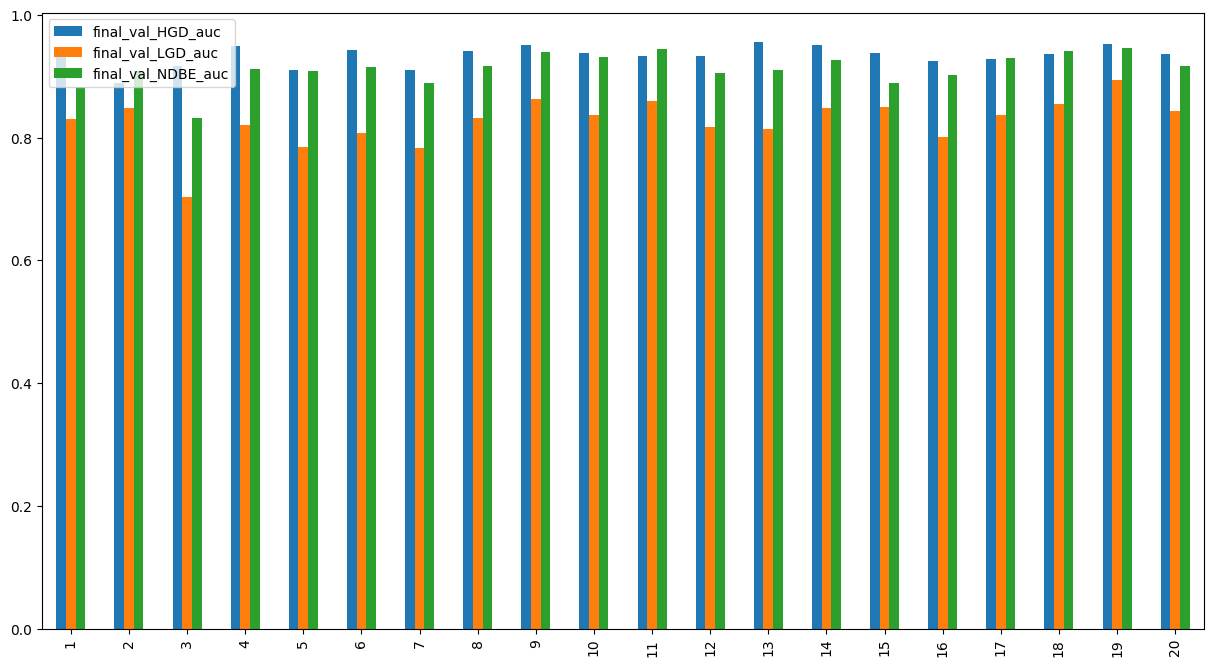

In [40]:
averaged_data[averaged_data.columns[averaged_data.columns.str.contains("auc")].tolist()].plot(kind='bar', figsize=(15,8))


<Axes: >

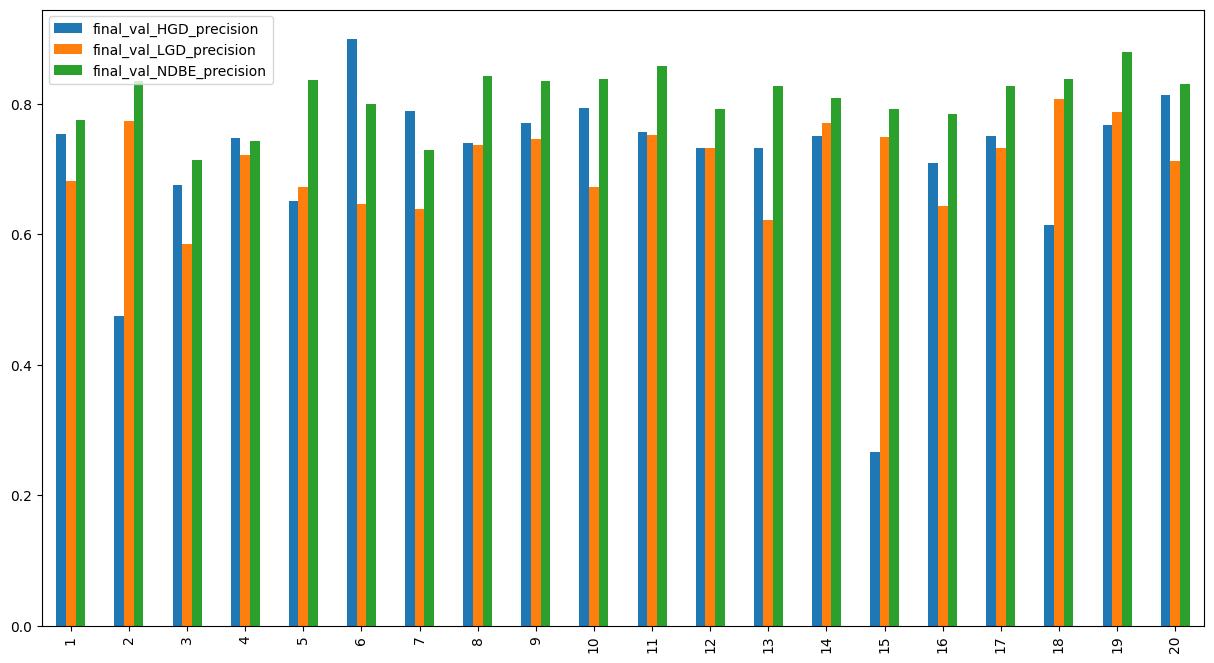

In [41]:
averaged_data[averaged_data.columns[averaged_data.columns.str.contains("precision")].tolist()].plot(kind='bar', figsize=(15,8))


<Axes: >

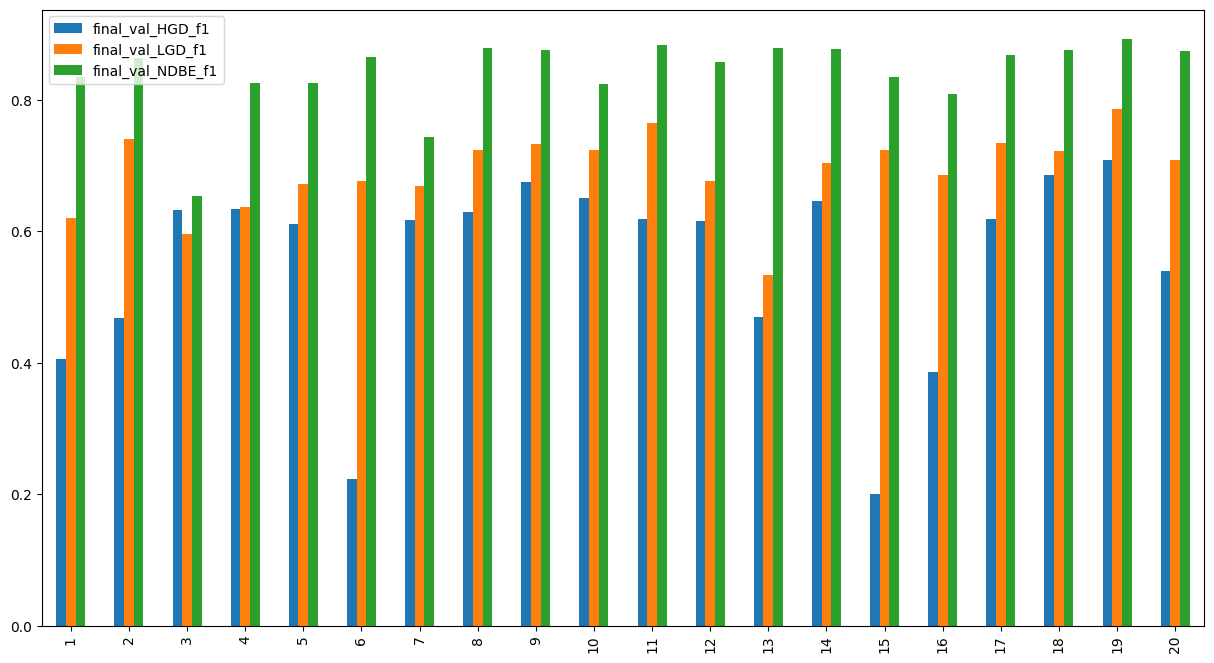

In [42]:
averaged_data[averaged_data.columns[averaged_data.columns.str.contains("f1")].tolist()].plot(kind='bar', figsize=(15,8))


<Axes: >

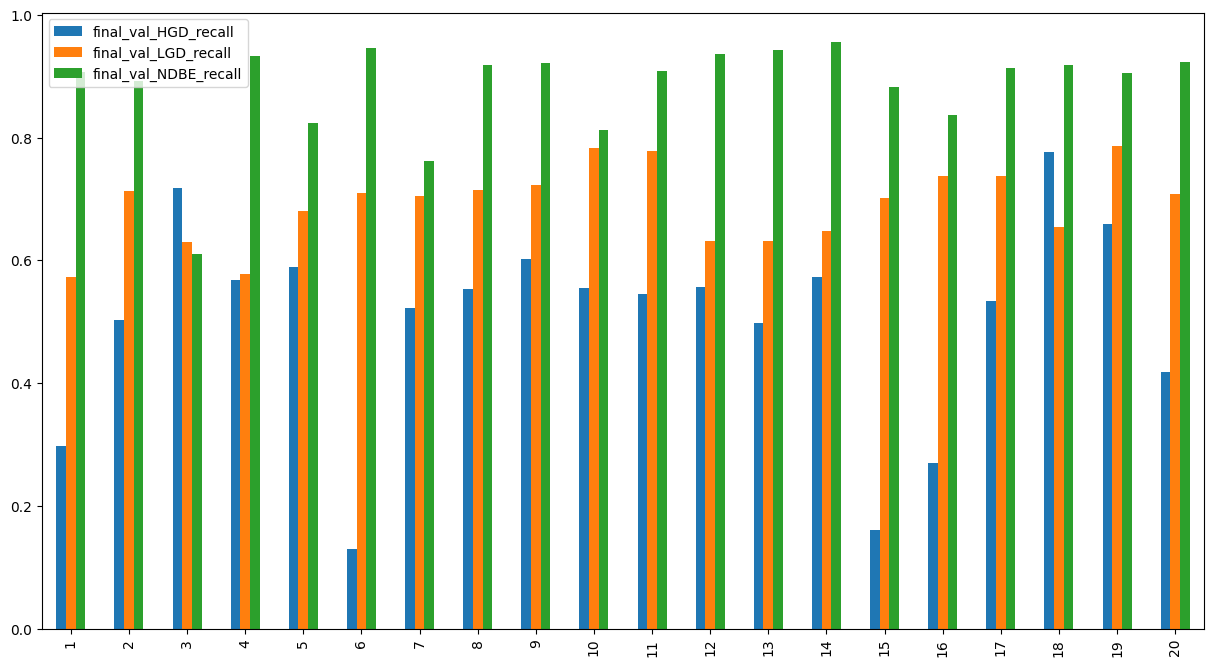

In [43]:
averaged_data[averaged_data.columns[averaged_data.columns.str.contains("recall")].tolist()].plot(kind='bar', figsize=(15,8))


<Axes: >

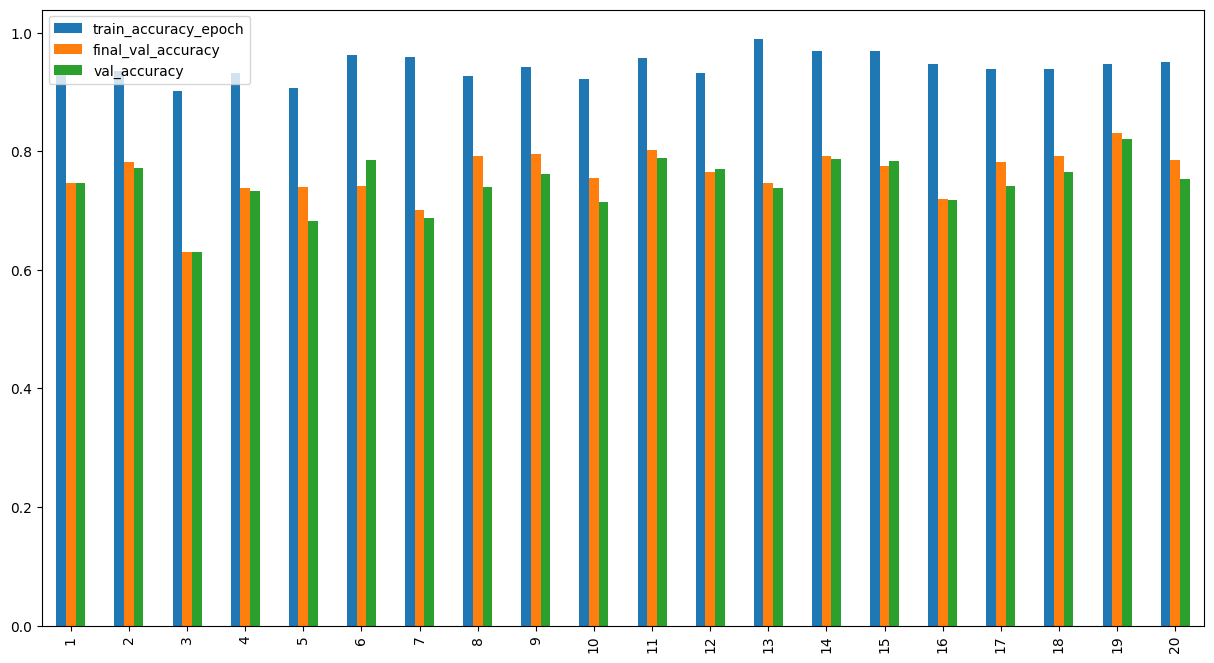

In [47]:
averaged_data[["train_accuracy_epoch", "final_val_accuracy", "val_accuracy"]].plot(kind='bar', figsize=(15,8))

<Axes: >

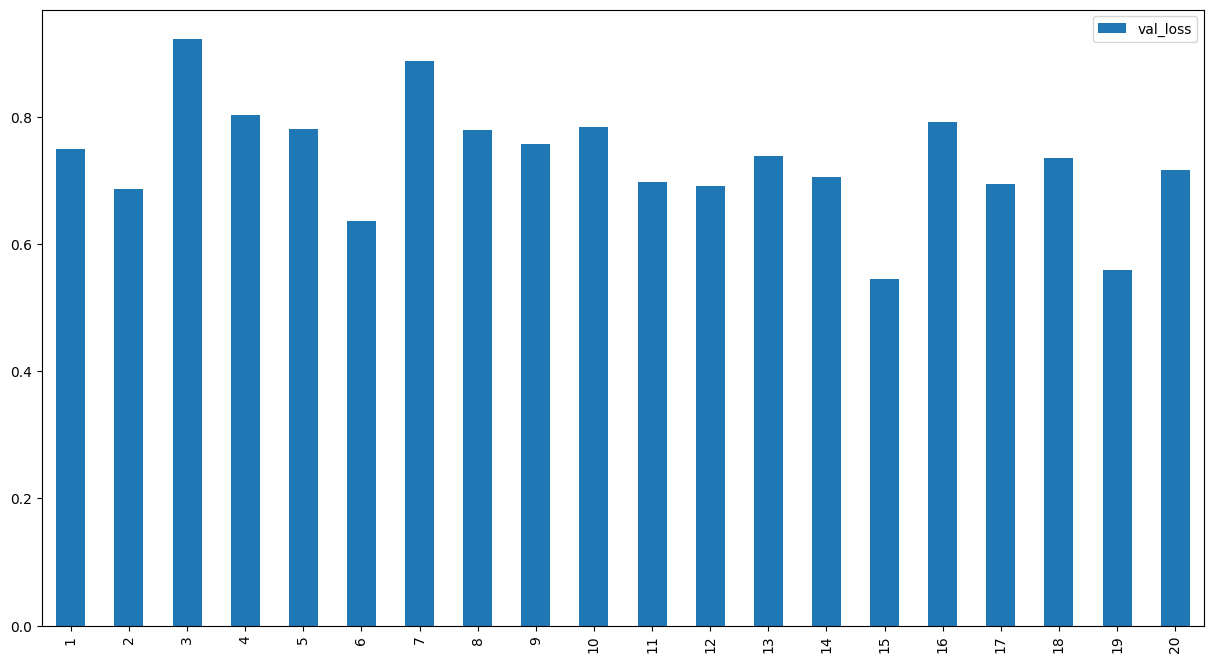

In [48]:
averaged_data[["val_loss"]].plot(kind='bar', figsize=(15,8))